<a href="https://colab.research.google.com/github/theoneureka/Computer-Vision-Project/blob/oshawott/ComputerVisionProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center><h1> <b> Object Classification Using YOLO <b> </h1></center>

<h1>YOU NEED TO RUN THIS</h1>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


This tutorial is designed to provide a comprehensive understanding of how to use YOLO, a state-of-the-art method in computer vision, for detecting objects in images.

Object detection and classification is a key technology in many areas, such as automated vehicles, security, and even healthcare.

We will begin with the basics of preparing (pre processing) an image dataset, ensuring it is ready for effective model training.We will then explore how YOLO, a type of convolutional neural network, automatically extracts features from images to recognize different objects. Understanding this process is crucial for grasping how YOLO operates.

The core of this tutorial is focused on transfer learning using YOLO. We will teach you how to take a pre-trained YOLO model and adapt it to a new dataset. This technique is efficient and powerful, allowing us to harness the strengths of YOLO with less computational effort.

By the end of this tutorial, you will have hands-on experience with preparing data, implementing YOLO, and understanding the principles behind it. This tutorial aims to equip students with practical skills and knowledge in one of the most exciting fields in technology.

Since its inception, the YOLO family of object detection models has come a long way. YOLOv8 is the most recent addition to this famous anchor-based single-shot family of object detectors. It comes with a bunch of improvements which include state-of-the-art accuracy and speed.  In this article, we will be fine tuning the YOLOv8 object detection model on a real-world pothole detection dataset.

In the previous lecture, you were asked to make your own custom datasets for a project you want to work on. Today we will explore how to finetune YOLO on a certain dataset.  

<h1>YOU NEED TO RUN THIS</h1>

Importing required Libraries

In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import cv2
import seaborn as sns
import glob
import xml.etree.ElementTree as ET
from PIL import Image
import os
import shutil

# Dataset Description






Plant Images for Object Classification

available on kaggle => https://www.kaggle.com/datasets/hanselliott/toxic-plant-classification


# Data Preprocessing

For preprocessing:
- We have to convert the dataset into that acceptable by YOLO.
  - Heirarchy of folders should be the one accepted by YOLO
- Check and see if there are any missing images. And remove them from dataset.


## Heirarchy of Folders correction

<h1>YOU NEED TO RUN THIS</h1>

Defining paths to train and test folders.

In [3]:
# train_dir = '/content/drive/MyDrive/project/train/Western_Poison_Oak'
# val_dir = '/content/drive/MyDrive/project/val/Western_Poison_Oak'

# train_dir2 = '/content/drive/MyDrive/project/train/Eastern_Poison_Oak'
# val_dir2 = '/content/drive/MyDrive/project/val/Eastern_Poison_Oak'

# train_dir3 = '/content/drive/MyDrive/project/train/Eastern_Poison_Ivy'
# val_dir3 = '/content/drive/MyDrive/project/val/Eastern_Poison_Ivy'

# train_dir4 = '/content/drive/MyDrive/project/train/Western_Poison_Ivy'
# val_dir4 = '/content/drive/MyDrive/project/val/Western_Poison_Ivy'

# train_dir5 = '/content/drive/MyDrive/project/train/Poison_Sumac'
# val_dir5 = '/content/drive/MyDrive/project/val/Poison_Sumac'

# train_dir6 = '/content/drive/MyDrive/project/train/Virginia_Creeper'
# val_dir6 = '/content/drive/MyDrive/project/val/Virginia_Creeper'

# train_dir7 = '/content/drive/MyDrive/project/train/Boxelder'
# val_dir7 = '/content/drive/MyDrive/project/val/Boxelder'

# train_dir8 = '/content/drive/MyDrive/project/train/Jack_In_The_Pulpit'
# val_dir8 = '/content/drive/MyDrive/project/val/Jack_In_The_Pulpit'

# train_dir9 = '/content/drive/MyDrive/project/train/Bear_Oak'
# val_dir9 = '/content/drive/MyDrive/project/val/Bear_Oak'

# train_dir10 = '/content/drive/MyDrive/project/train/Fragrant_Sumac'
# val_dir10 = '/content/drive/MyDrive/project/val/Fragrant_Sumac'

train_dir = '/content/drive/MyDrive/project/2/train/Western_Poison_Oak'
val_dir = '/content/drive/MyDrive/project/2/val/Western_Poison_Oak'

train_dir2 = '/content/drive/MyDrive/project/2/train/Eastern_Poison_Oak'
val_dir2 = '/content/drive/MyDrive/project/2/val/Eastern_Poison_Oak'

train_dir3 = '/content/drive/MyDrive/project/2/train/Eastern_Poison_Ivy'
val_dir3 = '/content/drive/MyDrive/project/2/val/Eastern_Poison_Ivy'

train_dir4 = '/content/drive/MyDrive/project/2/train/Western_Poison_Ivy'
val_dir4 = '/content/drive/MyDrive/project/2/val/Western_Poison_Ivy'

train_dir5 = '/content/drive/MyDrive/project/2/train/Poison_Sumac'
val_dir5 = '/content/drive/MyDrive/project/2/val/Poison_Sumac'

train_dir6 = '/content/drive/MyDrive/project/2/train/Virginia_Creeper'
val_dir6 = '/content/drive/MyDrive/project/2/val/Virginia_Creeper'

train_dir7 = '/content/drive/MyDrive/project/2/train/Boxelder'
val_dir7 = '/content/drive/MyDrive/project/2/val/Boxelder'

train_dir8 = '/content/drive/MyDrive/project/2/train/Jack_In_The_Pulpit'
val_dir8 = '/content/drive/MyDrive/project/2/val/Jack_In_The_Pulpit'

train_dir9 = '/content/drive/MyDrive/project/2/train/Bear_Oak'
val_dir9 = '/content/drive/MyDrive/project/2/val/Bear_Oak'

train_dir10 = '/content/drive/MyDrive/project/2/train/Fragrant_Sumac'
val_dir10 = '/content/drive/MyDrive/project/2/val/Fragrant_Sumac'



The train and test folders have all the images and labels together.

But for YOLO, the directories should be in:

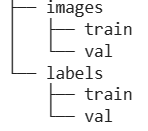


<h1 style="color: red;">ONLY NEEDS TO BE RUN ONCE!</h1>
<h2>YOU DO NOT NEED TO RUN THIS!</h2>
Making directories according to above struture of folders

In [ ]:
#import os
#run it once for making directories

# os.makedirs("/content/drive/MyDrive/project/Datasets/Final_data/images/train/Western_Poison_Oak", exist_ok=True)
# os.makedirs("/content/drive/MyDrive/project/Datasets/Final_data/images/train/Eastern_Poison_Oak", exist_ok=True)
# os.makedirs("/content/drive/MyDrive/project/Datasets/Final_data/images/train/Eastern_Poison_Ivy", exist_ok=True)
# os.makedirs("/content/drive/MyDrive/project/Datasets/Final_data/images/train/Western_Poison_Ivy", exist_ok=True)
# os.makedirs("/content/drive/MyDrive/project/Datasets/Final_data/images/train/Poison_Sumac", exist_ok=True)
# os.makedirs("/content/drive/MyDrive/project/Datasets/Final_data/images/train/Virginia_Creeper", exist_ok=True)
# os.makedirs("/content/drive/MyDrive/project/Datasets/Final_data/images/train/Boxelder", exist_ok=True)
# os.makedirs("/content/drive/MyDrive/project/Datasets/Final_data/images/train/Jack_In_The_Pulpit", exist_ok=True)
# os.makedirs("/content/drive/MyDrive/project/Datasets/Final_data/images/train/Bear_Oak", exist_ok=True)
# os.makedirs("/content/drive/MyDrive/project/Datasets/Final_data/images/train/Fragrant_Sumac", exist_ok=True)

# os.makedirs("/content/drive/MyDrive/project/Datasets/Final_data/images/val/Western_Poison_Oak", exist_ok=True)
# os.makedirs("/content/drive/MyDrive/project/Datasets/Final_data/images/val/Eastern_Poison_Oak", exist_ok=True)
# os.makedirs("/content/drive/MyDrive/project/Datasets/Final_data/images/val/Eastern_Poison_Ivy", exist_ok=True)
# os.makedirs("/content/drive/MyDrive/project/Datasets/Final_data/images/val/Western_Poison_Ivy", exist_ok=True)
# os.makedirs("/content/drive/MyDrive/project/Datasets/Final_data/images/val/Poison_Sumac", exist_ok=True)
# os.makedirs("/content/drive/MyDrive/project/Datasets/Final_data/images/val/Virginia_Creeper", exist_ok=True)
# os.makedirs("/content/drive/MyDrive/project/Datasets/Final_data/images/val/Boxelder", exist_ok=True)
# os.makedirs("/content/drive/MyDrive/project/Datasets/Final_data/images/val/Jack_In_The_Pulpit", exist_ok=True)
# os.makedirs("/content/drive/MyDrive/project/Datasets/Final_data/images/val/Bear_Oak", exist_ok=True)
# os.makedirs("/content/drive/MyDrive/project/Datasets/Final_data/images/val/Fragrant_Sumac", exist_ok=True)

os.makedirs("/content/drive/MyDrive/project/2/Datasets/Final_data/images/train/Western_Poison_Oak", exist_ok=True)
os.makedirs("/content/drive/MyDrive/project/2/Datasets/Final_data/images/train/Eastern_Poison_Oak", exist_ok=True)
os.makedirs("/content/drive/MyDrive/project/2/Datasets/Final_data/images/train/Eastern_Poison_Ivy", exist_ok=True)
os.makedirs("/content/drive/MyDrive/project/2/Datasets/Final_data/images/train/Western_Poison_Ivy", exist_ok=True)
os.makedirs("/content/drive/MyDrive/project/2/Datasets/Final_data/images/train/Poison_Sumac", exist_ok=True)
os.makedirs("/content/drive/MyDrive/project/2/Datasets/Final_data/images/train/Virginia_Creeper", exist_ok=True)
os.makedirs("/content/drive/MyDrive/project/2/Datasets/Final_data/images/train/Boxelder", exist_ok=True)
os.makedirs("/content/drive/MyDrive/project/2/Datasets/Final_data/images/train/Jack_In_The_Pulpit", exist_ok=True)
os.makedirs("/content/drive/MyDrive/project/2/Datasets/Final_data/images/train/Bear_Oak", exist_ok=True)
os.makedirs("/content/drive/MyDrive/project/2/Datasets/Final_data/images/train/Fragrant_Sumac", exist_ok=True)

os.makedirs("/content/drive/MyDrive/project/2/Datasets/Final_data/images/val/Western_Poison_Oak", exist_ok=True)
os.makedirs("/content/drive/MyDrive/project/2/Datasets/Final_data/images/val/Eastern_Poison_Oak", exist_ok=True)
os.makedirs("/content/drive/MyDrive/project/2/Datasets/Final_data/images/val/Eastern_Poison_Ivy", exist_ok=True)
os.makedirs("/content/drive/MyDrive/project/2/Datasets/Final_data/images/val/Western_Poison_Ivy", exist_ok=True)
os.makedirs("/content/drive/MyDrive/project/2/Datasets/Final_data/images/val/Poison_Sumac", exist_ok=True)
os.makedirs("/content/drive/MyDrive/project/2/Datasets/Final_data/images/val/Virginia_Creeper", exist_ok=True)
os.makedirs("/content/drive/MyDrive/project/2/Datasets/Final_data/images/val/Boxelder", exist_ok=True)
os.makedirs("/content/drive/MyDrive/project/2/Datasets/Final_data/images/val/Jack_In_The_Pulpit", exist_ok=True)
os.makedirs("/content/drive/MyDrive/project/2/Datasets/Final_data/images/val/Bear_Oak", exist_ok=True)
os.makedirs("/content/drive/MyDrive/project/2/Datasets/Final_data/images/val/Fragrant_Sumac", exist_ok=True)

<h1>YOU NEED TO RUN THIS PART</h1>

In [4]:
#set the paths to images directory
# image_dir="/content/drive/MyDrive/project/Datasets/Final_data/images"

image_dir="/content/drive/MyDrive/project/2/Datasets/Final_data/images"

<h1>ONLY NEEDS TO BE RUN ONCE!</h1>
<h2>YOU DO NOT NEED TO RUN THIS!</h2>
Set Full Training and Validation Folders for all Classes

In [ ]:
#Western Poison Oak
#run it once for copying!
for file in os.listdir(train_dir):
    if file.endswith(".jpg"):
        image = Image.open(os.path.join(train_dir, file))
        image = image.convert("RGB")
        new_filename = os.path.splitext(file)[0] + ".jpg"
        image.save(os.path.join(image_dir,"train/Western_Poison_Oak", new_filename), "JPEG")

for file in os.listdir(val_dir):
    if file.endswith(".jpg"):
        image = Image.open(os.path.join(val_dir, file))
        image = image.convert("RGB")
        new_filename = os.path.splitext(file)[0] + ".jpg"
        image.save(os.path.join(image_dir,"val/Western_Poison_Oak", new_filename), "JPEG")


In [ ]:
#Eastern Poison Oak
for file in os.listdir(train_dir2):
    if file.endswith(".jpg"):
        image = Image.open(os.path.join(train_dir2, file))
        image = image.convert("RGB")
        new_filename = os.path.splitext(file)[0] + ".jpg"
        image.save(os.path.join(image_dir,"train/Eastern_Poison_Oak", new_filename), "JPEG")

for file in os.listdir(val_dir2):
    if file.endswith(".jpg"):
        image = Image.open(os.path.join(val_dir2, file))
        image = image.convert("RGB")
        new_filename = os.path.splitext(file)[0] + ".jpg"
        image.save(os.path.join(image_dir,"val/Eastern_Poison_Oak", new_filename), "JPEG")

In [ ]:
#Eastern_Poison_Ivy
for file in os.listdir(train_dir3):
    if file.endswith(".jpg"):
        image = Image.open(os.path.join(train_dir3, file))
        image = image.convert("RGB")
        new_filename = os.path.splitext(file)[0] + ".jpg"
        image.save(os.path.join(image_dir,"train/Eastern_Poison_Ivy", new_filename), "JPEG")

for file in os.listdir(val_dir3):
    if file.endswith(".jpg"):
        image = Image.open(os.path.join(val_dir3, file))
        image = image.convert("RGB")
        new_filename = os.path.splitext(file)[0] + ".jpg"
        image.save(os.path.join(image_dir,"val/Eastern_Poison_Ivy", new_filename), "JPEG")

In [ ]:
#Western Poison Ivy
for file in os.listdir(train_dir4):
    if file.endswith(".jpg"):
        image = Image.open(os.path.join(train_dir4, file))
        image = image.convert("RGB")
        new_filename = os.path.splitext(file)[0] + ".jpg"
        image.save(os.path.join(image_dir,"train/Western_Poison_Ivy", new_filename), "JPEG")

for file in os.listdir(val_dir4):
    if file.endswith(".jpg"):
        image = Image.open(os.path.join(val_dir4, file))
        image = image.convert("RGB")
        new_filename = os.path.splitext(file)[0] + ".jpg"
        image.save(os.path.join(image_dir,"val/Western_Poison_Ivy", new_filename), "JPEG")

In [ ]:
#Poison_Sumac
for file in os.listdir(train_dir5):
    if file.endswith(".jpg"):
        image = Image.open(os.path.join(train_dir5, file))
        image = image.convert("RGB")
        new_filename = os.path.splitext(file)[0] + ".jpg"
        image.save(os.path.join(image_dir,"train/Poison_Sumac", new_filename), "JPEG")

for file in os.listdir(val_dir5):
    if file.endswith(".jpg"):
        image = Image.open(os.path.join(val_dir5, file))
        image = image.convert("RGB")
        new_filename = os.path.splitext(file)[0] + ".jpg"
        image.save(os.path.join(image_dir,"val/Poison_Sumac", new_filename), "JPEG")

In [ ]:
#Virginia_Creeper
for file in os.listdir(train_dir6):
    if file.endswith(".jpg"):
        image = Image.open(os.path.join(train_dir6, file))
        image = image.convert("RGB")
        new_filename = os.path.splitext(file)[0] + ".jpg"
        image.save(os.path.join(image_dir,"train/Virginia_Creeper", new_filename), "JPEG")

for file in os.listdir(val_dir6):
    if file.endswith(".jpg"):
        image = Image.open(os.path.join(val_dir6, file))
        image = image.convert("RGB")
        new_filename = os.path.splitext(file)[0] + ".jpg"
        image.save(os.path.join(image_dir,"val/Virginia_Creeper", new_filename), "JPEG")

In [ ]:
#Boxelder
for file in os.listdir(train_dir7):
    if file.endswith(".jpg"):
        image = Image.open(os.path.join(train_dir7, file))
        image = image.convert("RGB")
        new_filename = os.path.splitext(file)[0] + ".jpg"
        image.save(os.path.join(image_dir,"train/Boxelder", new_filename), "JPEG")

for file in os.listdir(val_dir7):
    if file.endswith(".jpg"):
        image = Image.open(os.path.join(val_dir7, file))
        image = image.convert("RGB")
        new_filename = os.path.splitext(file)[0] + ".jpg"
        image.save(os.path.join(image_dir,"val/Boxelder", new_filename), "JPEG")

In [ ]:
#Jack_In_The_Pulpit
for file in os.listdir(train_dir8):
    if file.endswith(".jpg"):
        image = Image.open(os.path.join(train_dir8, file))
        image = image.convert("RGB")
        new_filename = os.path.splitext(file)[0] + ".jpg"
        image.save(os.path.join(image_dir,"train/Jack_In_The_Pulpit", new_filename), "JPEG")

for file in os.listdir(val_dir8):
    if file.endswith(".jpg"):
        image = Image.open(os.path.join(val_dir8, file))
        image = image.convert("RGB")
        new_filename = os.path.splitext(file)[0] + ".jpg"
        image.save(os.path.join(image_dir,"val/Jack_In_The_Pulpit", new_filename), "JPEG")

In [ ]:
#Bear_Oak
for file in os.listdir(train_dir9):
    if file.endswith(".jpg"):
        image = Image.open(os.path.join(train_dir9, file))
        image = image.convert("RGB")
        new_filename = os.path.splitext(file)[0] + ".jpg"
        image.save(os.path.join(image_dir,"train/Bear_Oak", new_filename), "JPEG")

for file in os.listdir(val_dir9):
    if file.endswith(".jpg"):
        image = Image.open(os.path.join(val_dir9, file))
        image = image.convert("RGB")
        new_filename = os.path.splitext(file)[0] + ".jpg"
        image.save(os.path.join(image_dir,"val/Bear_Oak", new_filename), "JPEG")

In [ ]:
#Fragrant_Sumac
for file in os.listdir(train_dir10):
    if file.endswith(".jpg"):
        image = Image.open(os.path.join(train_dir10, file))
        image = image.convert("RGB")
        new_filename = os.path.splitext(file)[0] + ".jpg"
        image.save(os.path.join(image_dir,"train/Fragrant_Sumac", new_filename), "JPEG")

for file in os.listdir(val_dir10):
    if file.endswith(".jpg"):
        image = Image.open(os.path.join(val_dir10, file))
        image = image.convert("RGB")
        new_filename = os.path.splitext(file)[0] + ".jpg"
        image.save(os.path.join(image_dir,"val/Fragrant_Sumac", new_filename), "JPEG")

Visualizing somme pictures from the dataset

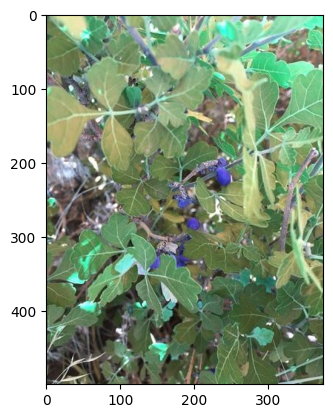

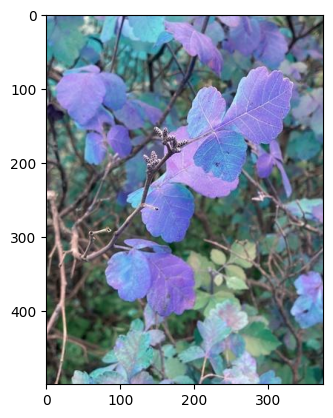

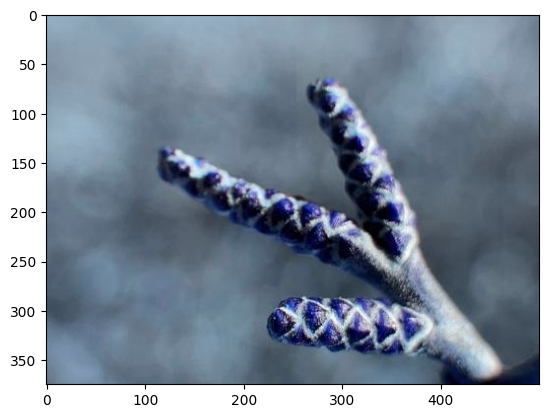

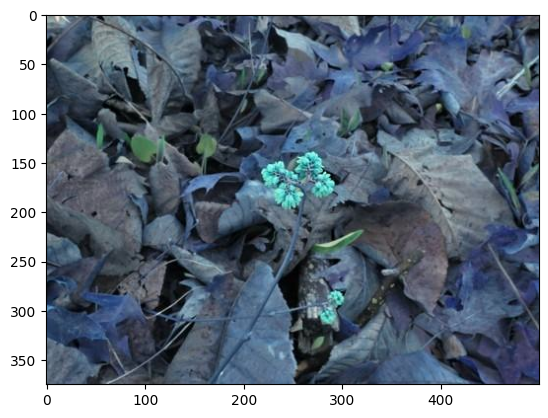

In [ ]:
#visualize first four sample images from train data
for idx, image in enumerate(os.listdir(os.path.join(image_dir, "train/Fragrant_Sumac"))):
    img = cv2.imread(os.path.join(image_dir,"train/Fragrant_Sumac", image), 1)
    plt.imshow(img)
    plt.show()

    if idx == 3:
        break

First install and import

In [5]:
%pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 46.7/112.6 GB disk)


In [6]:
from ultralytics import YOLO

## Training YOLO

Do not train this model

In [ ]:
model = YOLO('yolov8s-cls.pt') # pretrained model

In [ ]:
model.train(data="/content/drive/MyDrive/project/2/Datasets/Final_data/images",
            epochs=100,
            patience=10,
            batch=8,
            lr0=0.0005,
            imgsz=640,
            dropout=0.2,
            weight_decay=0.0005,
            translate=0.2,
            degrees=5,
            optimizer="AdamW",
            project="/content/drive/MyDrive/project/2/custom_folder_Eric")

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/project/2/Datasets/Final_data/images, degrees=5, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.25, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-20, nbs=64, nms=False, opset=None, optimize=False, optimizer

<h1>TRAIN WITH CURRMODEL</h1>

In [ ]:
model2 = YOLO('yolov8s-cls.pt') # pretrained model

In [ ]:
model2.train(data="/content/drive/MyDrive/project/2/Datasets/Final_data/images",
            epochs=100,
            patience=10,
            batch=8,
            lr0=0.0005,
            imgsz=640,
            dropout=0.2,
            weight_decay=0.0005,
            translate=0.2,
            degrees=5,
            optimizer="AdamW",
            project="/content/drive/MyDrive/project/2/custom_folder_Eric")

In [ ]:
model3 = YOLO('yolov8s-cls.pt') # pretrained model

In [ ]:
model3.train(data="/content/drive/MyDrive/project/2/Datasets/Final_data/images",
            epochs=100,
            patience=10,
            batch=8,
            lr0=0.0005,
            imgsz=640,
            dropout=0.2,
            weight_decay=0.0005,
            translate=0.2,
            degrees=5,
            optimizer="AdamW",
            project="/content/drive/MyDrive/project/2/custom_folder_Eric")

In [ ]:
model4 = YOLO('yolov8s-cls.pt') # pretrained model

In [ ]:
model4.train(data="/content/drive/MyDrive/project/2/Datasets/Final_data/images",
            epochs=100,
            patience=10,
            batch=8,
            lr0=0.0005,
            imgsz=640,
            dropout=0.2,
            weight_decay=0.0005,
            translate=0.2,
            degrees=5,
            optimizer="AdamW",
            project="/content/drive/MyDrive/project/2/custom_folder_Eric")

In [7]:
currmodel = YOLO('/content/drive/MyDrive/project/2/custom_folder_Eric/train-19/weights/best.pt')

Please look at [Yolo train Docs](https://docs.ultralytics.com/modes/train/#train-settings) for hyperparameters for model tuning and configuration, e.g. lr0, imgsz, model etc.

## Evaluation Metrics

[This](https://docs.ultralytics.com/guides/yolo-performance-metrics/) is a very good detailed explanation of different perfromance metrics in YOLO.

**Choosing the Right Metrics**

Choosing the right metrics to evaluate often depends on the specific application.

- mAP: Suitable for a broad assessment of model performance.

- IoU: Essential when precise object location is crucial.

- Precision: Important when minimizing false detections is a priority.

- Recall: Vital when it's important to detect every instance of an object.

- F1 Score: Useful when a balance between precision and recall is needed.


In [ ]:
bestmodel=YOLO('')

In [ ]:
# metrics = bestmodel.val(split="test", project="/content/drive/MyDrive/project/2/custom_folder_Eric")
metrics = currmodel.val(split="test", project="/content/drive/MyDrive/project/2/custom_folder_Eric")

print(metrics.top1)
print(metrics.summary())

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
train: /content/drive/MyDrive/project/2/Datasets/Final_data/images/train... found 2040 images in 10 classes ✅ 
val: /content/drive/MyDrive/project/2/Datasets/Final_data/images/val... found 240 images in 10 classes ✅ 
test: /content/drive/MyDrive/project/2/Datasets/Final_data/images/test... found 120 images in 10 classes ✅ 
WARNING ⚠️ test: Slow image access detected (ping: 1.1±0.7 ms, read: 39.9±30.2 MB/s, size: 156.2 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
test: Scanning /content/drive/MyDrive/project/2/Datasets/Final_data/images/test... 120 images, 0 corrupt: 100% ━━━━━━━━━━━━ 120/120 15.7Mit/s 0.0s
test: /content/drive/MyDrive/project/2/Datasets/Final_data/images/test/Western_Poison_Ivy/003-1.jpg: corrupt JPEG restored and saved
test: /content/drive/MyDrive/project/2/Datasets/Final_data/images/test/W

Showing confusion matrix, that is already stored in detect/train folder

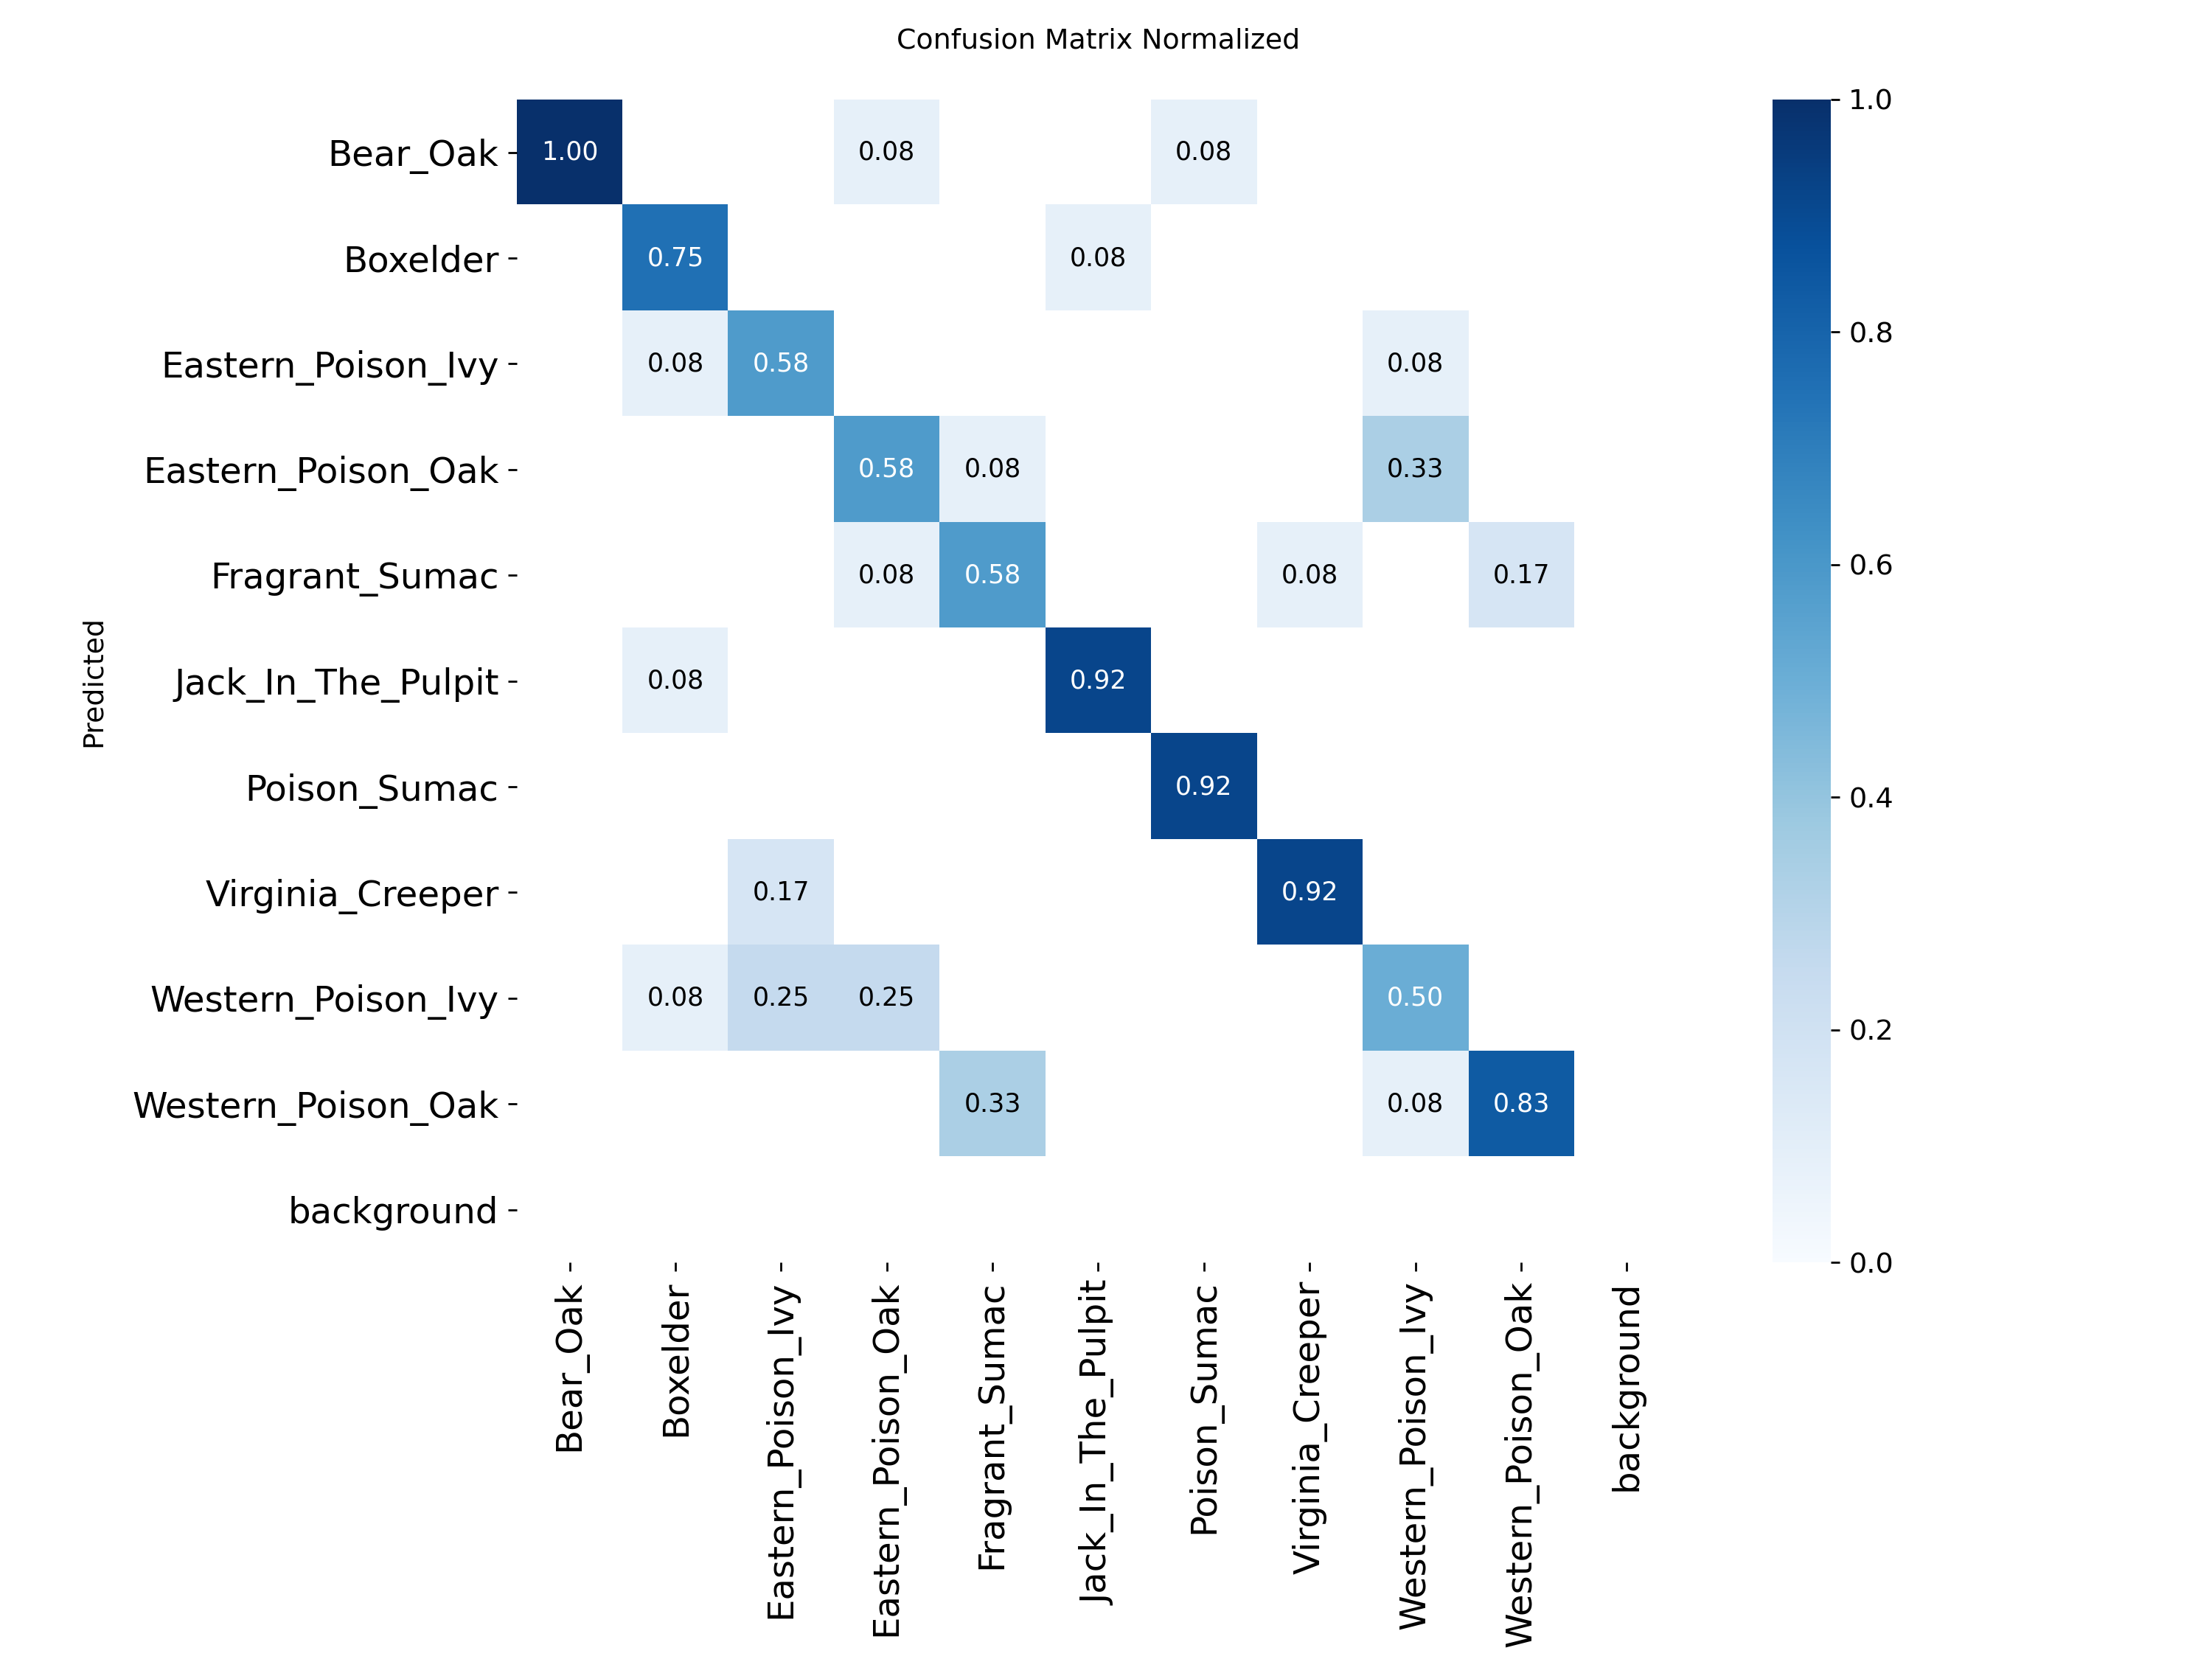

In [ ]:
%matplotlib inline
from PIL import Image

Image.open('/content/drive/MyDrive/project/2/custom_folder_Eric/val-14/confusion_matrix_normalized.png')

##Prediction

In [ ]:
model = YOLO("/content/drive/MyDrive/custom_folder/my_experiment/weights/best.pt")  # load a custom model

# Predict with the model with any image from internet?
results = model('https://www.freshpoint.com/wp-content/uploads/2019/08/freshpoint-produce-101-apples-bananas.jpg', save=True, project="/content/drive/MyDrive/custom_folder")


Found https://www.freshpoint.com/wp-content/uploads/2019/08/freshpoint-produce-101-apples-bananas.jpg locally at freshpoint-produce-101-apples-bananas.jpg
image 1/1 /content/freshpoint-produce-101-apples-bananas.jpg: 576x640 2 apples, 3 bananas, 16.4ms
Speed: 2.3ms preprocess, 16.4ms inference, 1.7ms postprocess per image at shape (1, 3, 576, 640)
Results saved to /content/drive/MyDrive/custom_folder/predict-2


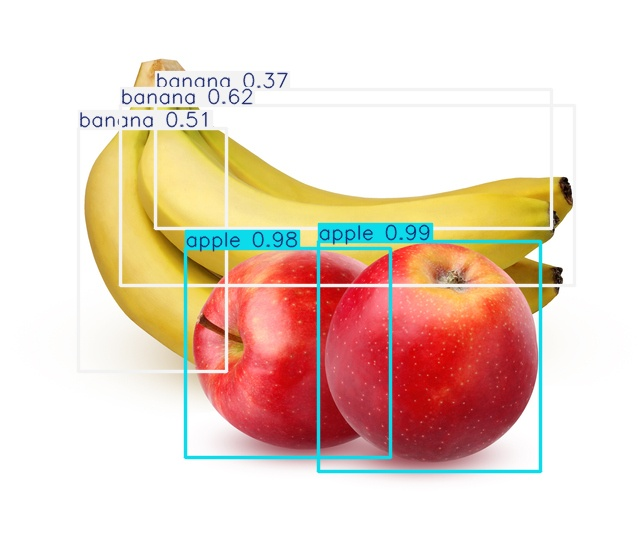

In [ ]:
# SHOW THE IMAGE STORED
%matplotlib inline
from PIL import Image

Image.open('/content/drive/MyDrive/custom_folder/predict-2/freshpoint-produce-101-apples-bananas.jpg')